In [1]:
import wandb
import pandas as pd
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, ttest_ind

from utils import compute_percent_improvement, WandbParser


api = wandb.Api()

In [2]:
def standard_post_processing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={"model_type": "model_name", "data_name": "dataset"})
    df["dataset"] = df["dataset"].str.replace("_", " ")
    df["model_name"] = df["model_name"].str.replace("_", " ")
    df["metric"] = df["metric"].str.replace("test/", "")

    # Corrected logic
    # bsarec_filter = (
    #     (df["model_name"] == "BSARec") &
    #     (
    #         ((df["dataset"] == "MIND") & (df["c"] == 7) & (df["lr"] == 0.005) & (df["num_attention_heads"] == 1) & (df["alpha"] == 0.5)) |
    #         ((df["dataset"] == "taobao small") & (df["c"] == 9) & (df["lr"] == 0.005) & (df["num_attention_heads"] == 4) & (df["alpha"] == 0.7))
    #     )
    # )
    
    # # Invert to keep only these runs for BSARec; all others (non-matching BSARec configs) are dropped
    # df = df[~((df["model_name"] == "BSARec") & ~bsarec_filter)]

    # df = df.drop(columns=["c", "lr", "num_attention_heads", "alpha"])

    return df

In [7]:
wandb_parser = WandbParser(entity="bsarec", api=api, verbose=True)

# models = ["SASRec", "BERT4Rec", "FMLPRec", "duoRec", "FeaRec", "BSARec", "BSARec_Wavelet"]
models = ["BSARec_Padding", "SASRec", "FMLPRec", "BERT4REC"]\

datasets = [
    'ML-1M',
    'LastFM',
    'Yelp'
    # 'Sports_and_Outdoors',
    # 'Toys_and_Games',
    # 'Yelp'
]
max_seq_lengths = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
metrics = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]
# seed = [37, 5166, 3817]
seed = None

# add reproduction runs
wandb_parser.register_project(
    project="padding_experiment_lenghts_final",
    model_type=models,
    data_name=datasets,
    seed=seed,
    max_seq_length=max_seq_lengths
)

df = wandb_parser.parse(
    cfg=["model_type", "data_name", "seed", "c", "lr", "num_attention_heads", "alpha", "max_seq_length", 'run_name', 'padding', 'batch_size'],
    summary=[f"test/{metric_name}" for metric_name in metrics],
    post_processing=standard_post_processing
)

# df.model_name bsarec_padding is bsarec
df["model_name"] = df["model_name"].str.replace("BSARec Padding", "BSARec")
df = df[df.batch_size == 256]
df_immutable = df.copy(deep=True)

# for every model, dataset, metric and max_seq_length, take a single sample randomly
def sample_single_run(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)
df_sampled = sample_single_run(df)

Added padding_experiment_lenghts_final to parser
Loading runs from padding_experiment_lenghts_final with filters {'config.model_type': {'$in': ['BSARec_Padding', 'SASRec', 'FMLPRec', 'BERT4REC']}, 'config.data_name': {'$in': ['ML-1M', 'LastFM', 'Yelp']}, 'config.max_seq_length': {'$in': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}, 'state': {'$in': ['finished']}}
Applying post processing


/scratch-local/67564/ipykernel_3890653/755382216.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)


In [8]:
df.model_name.value_counts()

model_name
FMLPRec     1632
SASRec      1620
BERT4REC    1620
BSARec       426
Name: count, dtype: int64

In [ ]:
wandb_parser = WandbParser(entity="bsarec", api=api, verbose=True)

# models = ["SASRec", "BERT4Rec", "FMLPRec", "duoRec", "FeaRec", "BSARec", "BSARec_Wavelet"]
models = ["BSARec_Padding", "BSARec"]
datasets = [
    'ML-1M',
    'ML-10M',
    'ML-20M',
    'ML-32M'
    # 'Sports_and_Outdoors',
    # 'Toys_and_Games',
    # 'Yelp'
]
max_seq_lengths = [150]
metrics = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]
# seed = [37, 5166, 3817]
seed = None

# add reproduction runs
wandb_parser.register_project(
    project="padding_experiment_lenghts_final",
    model_type=models,
    data_name=datasets,
    seed=seed,
    max_seq_length=max_seq_lengths
)

df = wandb_parser.parse(
    cfg=["model_type", "data_name", "seed", "c", "lr", "num_attention_heads", "alpha", "max_seq_length", 'run_name', 'padding'],
    summary=[f"test/{metric_name}" for metric_name in metrics],
    post_processing=standard_post_processing
)
df.dropna(inplace=True)
df['size'] = df['dataset'].str.extract(r'ML-(\d+)M').astype(int)
df["model_name"] = df["model_name"].str.replace("BSARec Padding", "BSARec")


df_immutable = df.copy(deep=True)


# for every model, dataset, metric and max_seq_length, take a single sample randomly
def sample_single_run(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)
df_sampled = sample_single_run(df)

Added padding_experiment_lenghts_final to parser
Loading runs from padding_experiment_lenghts_final with filters {'config.model_type': {'$in': ['BSARec_Padding', 'BSARec']}, 'config.data_name': {'$in': ['ML-1M', 'ML-10M', 'ML-20M', 'ML-32M']}, 'config.max_seq_length': {'$in': [150]}, 'state': {'$in': ['finished']}}
Applying post processing


/scratch-local/67564/ipykernel_635411/390521277.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)


: 

In [ ]:
wandb_parser = WandbParser(entity="bsarec", api=api, verbose=True)

# models = ["SASRec", "BERT4Rec", "FMLPRec", "duoRec", "FeaRec", "BSARec", "BSARec_Wavelet"]
models = ["BSARec", "BSARec_Padding", "SASRec", "DuoRec", "BERT4REC"]
datasets = [
    'ML-1M',
    # 'Sports_and_Outdoors',
    # 'Toys_and_Games',
    # 'Yelp'
]
max_seq_lengths = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
metrics = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]
# seed = [37, 5166, 3817]
seed = None

# add reproduction runs
wandb_parser.register_project(
    project="padding_experiment_lenghts_final",
    model_type=models,
    data_name=datasets,
    seed=seed,
    max_seq_length=max_seq_lengths
)

df = wandb_parser.parse(
    cfg=["model_type", "data_name", "seed", "c", "lr", "num_attention_heads", "alpha", "max_seq_length", 'run_name', 'padding', 'batch_size'],
    summary=[f"test/{metric_name}" for metric_name in metrics],
    post_processing=standard_post_processing
)

# df.model_name bsarec_padding is bsarec
df["model_name"] = df["model_name"].str.replace("BSARec Padding", "BSARec")
df = df[df.batch_size == 256]

df_immutable = df.copy(deep=True)

# for every model, dataset, metric and max_seq_length, take a single sample randomly
def sample_single_run(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)
df_sampled = sample_single_run(df)

Added padding_experiment_lenghts_final to parser
Loading runs from padding_experiment_lenghts_final with filters {'config.model_type': {'$in': ['BSARec', 'BSARec_Padding', 'SASRec', 'DuoRec', 'BERT4REC']}, 'config.data_name': {'$in': ['ML-1M']}, 'config.max_seq_length': {'$in': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}, 'state': {'$in': ['finished']}}
Applying post processing


/scratch-local/67564/ipykernel_644930/1163645442.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)


: 

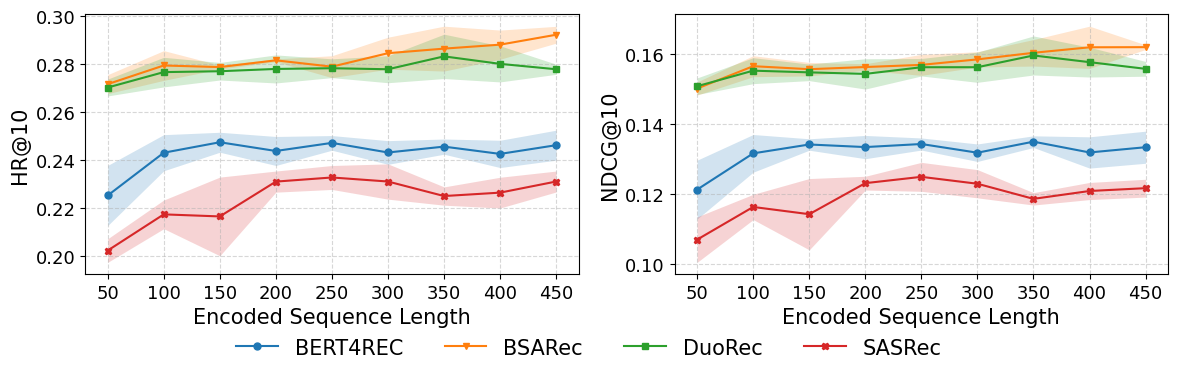

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({
    "font.size": 14,              # Base font size
    "axes.titlesize": 16,         # Axes title font
    "axes.labelsize": 15,         # Axes label font
    "xtick.labelsize": 13,        # X tick labels
    "ytick.labelsize": 13,        # Y tick labels
    "legend.fontsize": 15,        # Legend font
})
# Sort data
df_sampled = df.sort_values(by=["model_name", "dataset", "max_seq_length", "padding"])

# Metrics, markers, and color palette
metrics = ["HR@10", "NDCG@10"]
markers = ["o", "v", "s", "X", "D", "^", "*"]
tab10_colors = plt.get_cmap("tab10").colors

# Aggregate mean and std for error bands
df_stats = df_sampled.groupby(
    ["model_name", "dataset", "padding", "max_seq_length", "metric"], as_index=False
).agg(
    mean_value=("value", "mean"),
    std_value=("value", "std")
)

# Filter to padding == 'zero' only
df_stats = df_stats[df_stats["padding"] == 'zero']

# Get dataset name (only one expected)
dataset_name = df_stats["dataset"].unique()[0]

# Create side-by-side plots: one for each metric
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)
axes = axes.flatten()

# Store handles for legend once
legend_handles = []
legend_labels = []

for ax_idx, metric in enumerate(metrics):
    ax = axes[ax_idx]
    metric_df = df_stats[df_stats["metric"] == metric]

    for idx, model_name in enumerate(sorted(metric_df["model_name"].unique())):
        model_df = metric_df[metric_df["model_name"] == model_name]
        color = tab10_colors[idx % len(tab10_colors)]
        marker = markers[idx % len(markers)]

        x = model_df["max_seq_length"]
        y = model_df["mean_value"]
        yerr = model_df["std_value"]

        line = ax.plot(
            x,
            y,
            marker=marker,
            color=color,
            label=model_name,
            linestyle='-',
            markersize=5,
            linewidth=1.5,
        )[0]

        ax.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=color,
            alpha=0.2,
            linewidth=0
        )

        # Collect legend info only once (on first metric plot)
        if ax_idx == 0:
            legend_handles.append(line)
            legend_labels.append(model_name)

    ax.set_xlabel("Encoded Sequence Length")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(metric_df["max_seq_length"].unique()))


# One shared legend under both plots
fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(legend_labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f"model_comparison_{dataset_name}.pdf")
plt.show()


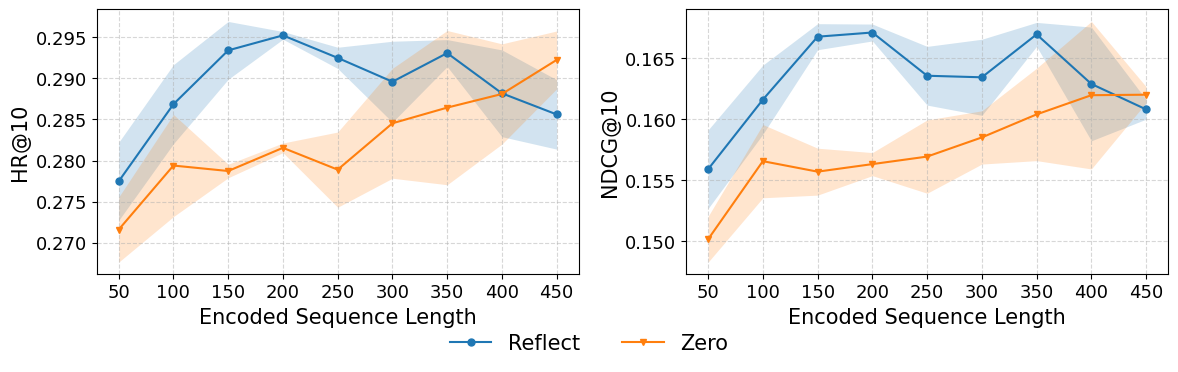

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort data
df_sampled = df.sort_values(by=["model_name", "dataset", "max_seq_length", "padding"])

# Metrics, markers, and color palette
metrics = ["HR@10", "NDCG@10"]
markers = ["o", "v", "s", "X", "D", "^", "*"]
tab10_colors = plt.get_cmap("tab10").colors

# Aggregate mean and std for error bands
df_stats = df_sampled.groupby(
    ["model_name", "dataset", "padding", "max_seq_length", "metric"], as_index=False
).agg(
    mean_value=("value", "mean"),
    std_value=("value", "std")
)

# Filter to only BSARec_Padding
df_stats = df_stats[df_stats["model_name"] == "BSARec"]

# Get dataset name (only one expected)
dataset_name = df_stats["dataset"].unique()[0]

# Create side-by-side plots: one for each metric
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)
axes = axes.flatten()

# Store handles for shared legend
legend_handles = []
legend_labels = []

for ax_idx, metric in enumerate(metrics):
    ax = axes[ax_idx]
    metric_df = df_stats[df_stats["metric"] == metric]

    for idx, padding_type in enumerate(sorted(metric_df["padding"].unique())):
        padding_df = metric_df[metric_df["padding"] == padding_type]
        color = tab10_colors[idx % len(tab10_colors)]
        marker = markers[idx % len(markers)]

        x = padding_df["max_seq_length"]
        y = padding_df["mean_value"]
        yerr = padding_df["std_value"]

        line = ax.plot(
            x,
            y,
            marker=marker,
            color=color,
            label=padding_type,
            linestyle='-',
            markersize=5,
            linewidth=1.5,
        )[0]

        ax.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=color,
            alpha=0.2,
            linewidth=0
        )

        # Collect legend only once
        if ax_idx == 0:
            legend_handles.append(line)
            legend_labels.append(padding_type.capitalize())

    ax.set_xlabel("Encoded Sequence Length")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(metric_df["max_seq_length"].unique()))


# One shared legend below
fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=len(legend_labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f"BSARec_Padding_comparison_{dataset_name}.pdf")
plt.show()


In [14]:
wandb_parser = WandbParser(entity="bsarec", api=api, verbose=True)

# models = ["SASRec", "BERT4Rec", "FMLPRec", "duoRec", "FeaRec", "BSARec", "BSARec_Wavelet"]
models = ["BSARec_Padding", "Bsarec_skip", 'BSARec_Wavelet']
datasets = [
    'ML-1M',
    # 'Sports_and_Outdoors',
    # 'Toys_and_Games',
    # 'Yelp'
]
max_seq_lengths = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
metrics = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]
# seed = [37, 5166, 3817]
seed = None

# add reproduction runs
wandb_parser.register_project(
    project="padding_experiment_lenghts_final",
    model_type=models,
    data_name=datasets,
    seed=seed,
    max_seq_length=max_seq_lengths
)

df = wandb_parser.parse(
    cfg=["model_type", "data_name", "seed", "c", "lr", "num_attention_heads", "alpha", "max_seq_length", 'run_name', 'padding', 'batch_size'],
    summary=[f"test/{metric_name}" for metric_name in metrics],
    post_processing=standard_post_processing
)

# df.model_name bsarec_padding is bsarec
df["model_name"] = df["model_name"].str.replace("BSARec Padding", "BSARec")
df["model_name"] = df["model_name"].str.replace("Bsarec skip", "BSARec (Residual)")
df["model_name"] = df["model_name"].str.replace("BSARec Wavelet", "BSARec (Wavelet)")
df["model_name"] = df["model_name"].str.replace("fourier", "BSARec (No Attention)")

df = df[df.batch_size == 256]
df_immutable = df.copy(deep=True)

# for every model, dataset, metric and max_seq_length, take a single sample randomly
def sample_single_run(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)
df_sampled = sample_single_run(df)

Added padding_experiment_lenghts_final to parser
Loading runs from padding_experiment_lenghts_final with filters {'config.model_type': {'$in': ['BSARec_Padding', 'Bsarec_skip', 'BSARec_Wavelet']}, 'config.data_name': {'$in': ['ML-1M']}, 'config.max_seq_length': {'$in': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}, 'state': {'$in': ['finished']}}
Applying post processing


/scratch-local/67564/ipykernel_3890653/673511713.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["model_name", "dataset", "metric", "max_seq_length", "padding"]).apply(lambda x: x.sample(1)).reset_index(drop=True)


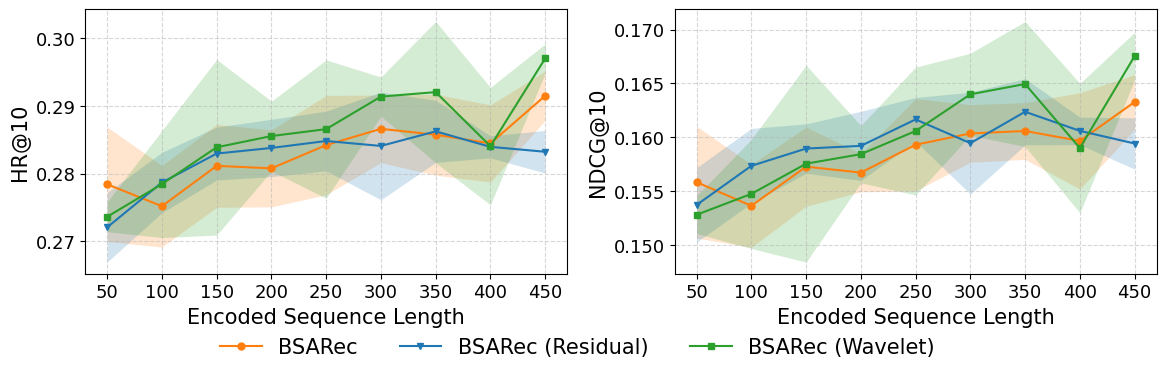

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({
    "font.size": 14,              # Base font size
    "axes.titlesize": 16,         # Axes title font
    "axes.labelsize": 15,         # Axes label font
    "xtick.labelsize": 13,        # X tick labels
    "ytick.labelsize": 13,        # Y tick labels
    "legend.fontsize": 15,        # Legend font
})
# Sort data
df_sampled = df.sort_values(by=["model_name", "dataset", "max_seq_length", "padding"])

# Metrics, markers, and color palette
metrics = ["HR@10", "NDCG@10"]
markers = ["o", "v", "s", "X", "D", "^", "*"]
tab10_colors = plt.get_cmap("tab10").colors

# Aggregate mean and std for error bands
df_stats = df_sampled.groupby(
    ["model_name", "dataset", "padding", "max_seq_length", "metric"], as_index=False
).agg(
    mean_value=("value", "mean"),
    std_value=("value", "std")
)

# Filter to padding == 'zero' only
df_stats = df_stats[df_stats["padding"] == 'zero']

# Get dataset name (only one expected)
dataset_name = df_stats["dataset"].unique()[0]

# Create side-by-side plots: one for each metric
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)
axes = axes.flatten()

# Store handles for legend once
legend_handles = []
legend_labels = []

for ax_idx, metric in enumerate(metrics):
    ax = axes[ax_idx]
    metric_df = df_stats[df_stats["metric"] == metric]

    for idx, model_name in enumerate(sorted(metric_df["model_name"].unique())):
        model_df = metric_df[metric_df["model_name"] == model_name]
        
        # Use orange for BSARec, otherwise use tab10 palette
        if model_name == "BSARec":
            color = "tab:orange"
        elif model_name == "BSARec (Residual)":
            color = "tab:blue"
        else:
            color = tab10_colors[idx % len(tab10_colors)]
            
        marker = markers[idx % len(markers)]

        x = model_df["max_seq_length"]
        y = model_df["mean_value"]
        yerr = model_df["std_value"]

        line = ax.plot(
            x,
            y,
            marker=marker,
            color=color,
            label=model_name,
            linestyle='-',
            markersize=5,
            linewidth=1.5,
        )[0]

        ax.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=color,
            alpha=0.2,
            linewidth=0
        )

        if ax_idx == 0:
            legend_handles.append(line)
            legend_labels.append(model_name)

        ax.set_xlabel("Encoded Sequence Length")
        ax.set_ylabel(metric)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xticks(sorted(metric_df["max_seq_length"].unique()))


# One shared legend under both plots
fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(legend_labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f"ablation_comparison_{dataset_name}.pdf")
plt.show()
